In [16]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [17]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,0e321_00002,0,0.464154,least_confidence,3,235.617338
1,1,0e321_00002,1,0.449651,least_confidence,3,235.617338
2,2,0e321_00002,2,0.548364,least_confidence,3,235.617338
3,3,0e321_00002,3,0.841550,least_confidence,3,235.617338
4,4,0e321_00002,4,0.798247,least_confidence,3,235.617338
...,...,...,...,...,...,...,...
5768,5768,0e321_00024,246,0.936336,random,5,230.875113
5769,5769,0e321_00024,247,0.937722,random,5,230.875113
5770,5770,0e321_00024,248,0.941917,random,5,230.875113
5771,5771,0e321_00024,249,0.945077,random,5,230.875113


In [18]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
4518,4518,0e321_00020,0,0.570773,random,1,232.745459
4519,4519,0e321_00020,1,0.869639,random,1,232.745459
4520,4520,0e321_00020,2,0.751917,random,1,232.745459
4521,4521,0e321_00020,3,0.710974,random,1,232.745459
4522,4522,0e321_00020,4,0.701026,random,1,232.745459
...,...,...,...,...,...,...,...
5768,5768,0e321_00024,246,0.936336,random,5,230.875113
5769,5769,0e321_00024,247,0.937722,random,5,230.875113
5770,5770,0e321_00024,248,0.941917,random,5,230.875113
5771,5771,0e321_00024,249,0.945077,random,5,230.875113


In [19]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{row.avg:.2f} ± {row.stdv:.2f}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

/var/folders/02/fbyrwz_s7tg4vmbm1kswhxp40000gp/T/ipykernel_23455/2952143151.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])


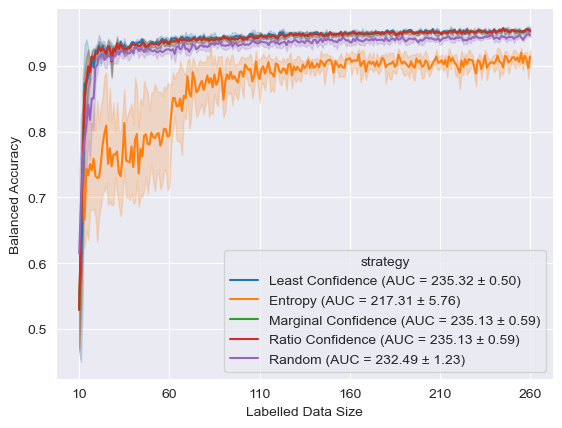

In [20]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Balanced Accuracy")
plt.xlabel("Labelled Data Size")

current_xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
    

for spine in ax.spines.values():
    spine.set_visible(False)